In [1]:
!pip install gudhi --quiet
!pip install scikit-tda --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ripser
import persim

In [3]:
LHR1 = pd.read_csv("LargeHypoxicRegion.csv")
LHR2 = pd.read_csv("LargeHypoxicRegion2.csv")

In [4]:
LHR1.head(5)

,x,y,PanCK+,CAIX+,Pimo+,Necrosis,Celltype
0,2.86,526.43,0,0,0,0,CD8
1,2.59,573.32,0,0,0,0,CD8
2,9.26,596.48,0,0,0,0,CD8
3,2.55,842.17,0,0,0,0,CD8
4,7.02,1044.55,0,0,0,0,CD8


In [5]:
LHR2.head(5)

,x,y,PanCK+,CAIX+,Pimo+,Necrosis,Celltype
0,2.59,67.20,0,0,0,0,CD8
1,7.99,106.15,0,1,0,0,CD8
2,3.25,373.03,0,0,0,0,CD8
3,8.40,480.41,0,0,0,0,CD8
4,3.93,572.57,0,0,0,0,CD8


/tmp/ipykernel_1958/2644948167.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=LHR1, x='Celltype', palette='viridis')


Text(0, 0.5, 'Total number of cells')

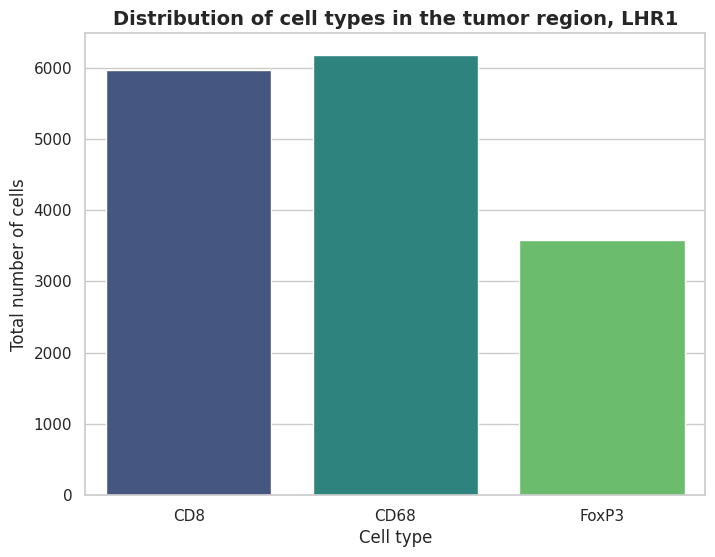

In [6]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

sns.countplot(data=LHR1, x='Celltype', palette='viridis')

plt.title('Distribution of cell types in the tumor region, LHR1', fontsize=14, fontweight='bold')
plt.xlabel('Cell type', fontsize=12)
plt.ylabel('Total number of cells', fontsize=12)

/tmp/ipykernel_1958/66872007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=LHR2, x='Celltype', palette='viridis')


Text(0, 0.5, 'Total number of cells')

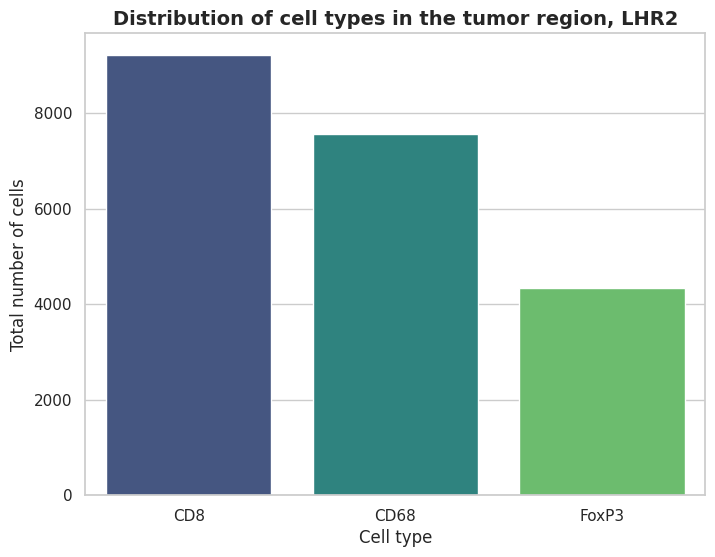

In [7]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))

sns.countplot(data=LHR2, x='Celltype', palette='viridis')

plt.title('Distribution of cell types in the tumor region, LHR2', fontsize=14, fontweight='bold')
plt.xlabel('Cell type', fontsize=12)
plt.ylabel('Total number of cells', fontsize=12)

- **CD8**: Their primary function is to identify and directly destroy infected or malignant cells. In the tumor microenvironment, a high spatial infiltration of CD8+ T cells within the tumor core is generally associated with a strong anti-tumor immune response and a better patient prognosis

- **CD68**: CD68 is a widely used pan-macrophage marker. These cells are specialized in phagocytosis (engulfing cellular debris and pathogens).

- **FoxP3**: Their primary role is to suppress immune responses and prevent autoimmunity. However, in cancer, a high infiltration of FoxP3 cells is generally a negative sign, as they actively inhibit the tumor-killing functions of the CD8 cells

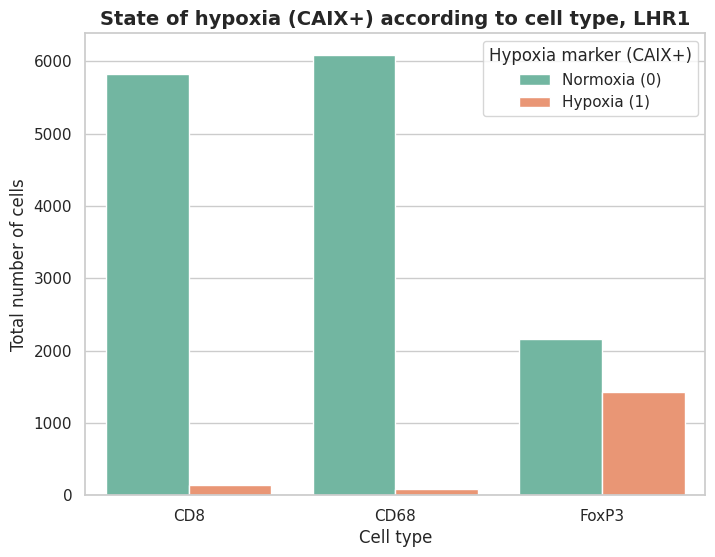

In [8]:
plt.figure(figsize=(8, 6))

sns.countplot(data=LHR1, x='Celltype', hue='CAIX+', palette='Set2')

plt.title('State of hypoxia (CAIX+) according to cell type, LHR1', fontsize=14, fontweight='bold')
plt.xlabel('Cell type', fontsize=12)
plt.ylabel('Total number of cells', fontsize=12)

# Personnaliser la légende pour que ce soit clair pour votre auditoire
plt.legend(title='Hypoxia marker (CAIX+)', labels=['Normoxia (0)', 'Hypoxia (1)'])

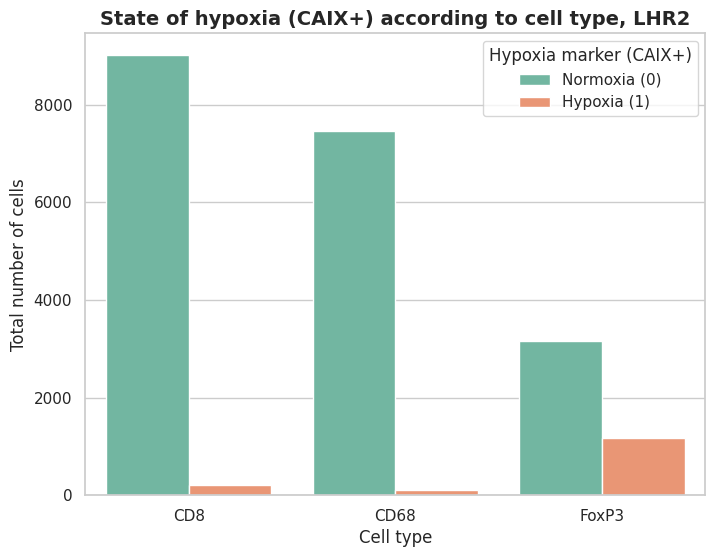

In [9]:
plt.figure(figsize=(8, 6))

sns.countplot(data=LHR2, x='Celltype', hue='CAIX+', palette='Set2')

plt.title('State of hypoxia (CAIX+) according to cell type, LHR2', fontsize=14, fontweight='bold')
plt.xlabel('Cell type', fontsize=12)
plt.ylabel('Total number of cells', fontsize=12)

plt.legend(title='Hypoxia marker (CAIX+)', labels=['Normoxia (0)', 'Hypoxia (1)'])

**Hypoxia (Low Oxygen)**: Hypoxia refers to regions within the tissue that are deprived of adequate oxygen. As solid tumors grow rapidly, they often outstrip their local blood supply, creating these oxygen-starved areas. In cancer, hypoxia is a strong negative prognostic factor: it drives tumor aggressiveness, increases resistance to therapies (like radiation), and creates a highly immunosuppressive microenvironment that inhibits the function of CD8+ cells while promoting suppressive cells like FoxP3+.

**CAIX+ / Pimo+ (Hypoxia Markers)**: These are the specific markers used in the dataset to identify hypoxic cells. CAIX (Carbonic Anhydrase IX) is an endogenous protein produced by cells to survive low oxygen levels, while Pimo (Pimonidazole) is an exogenous chemical tracer that specifically binds to oxygen-deprived cells

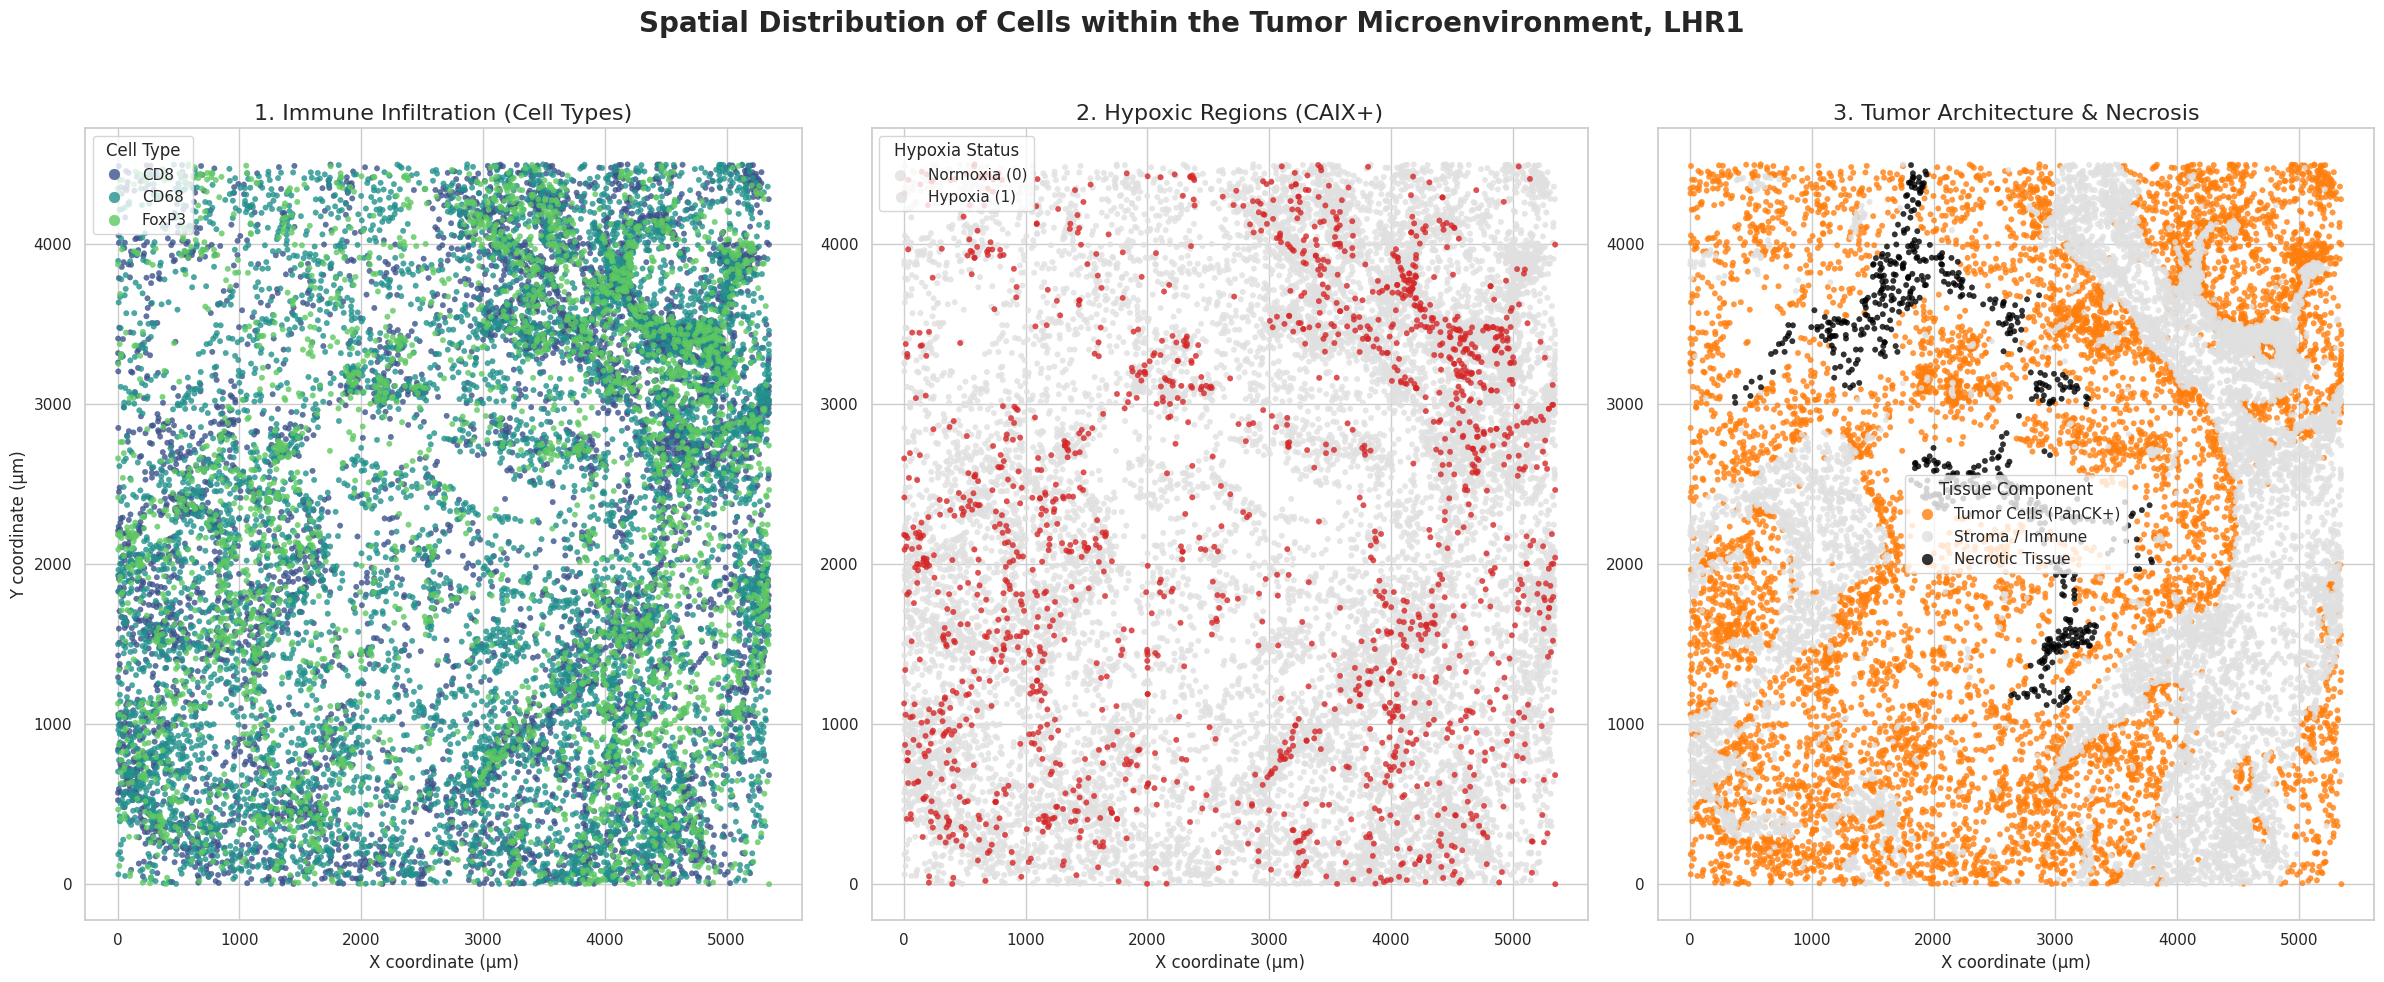

In [10]:
df1 = LHR1.copy()

conditions = [
    (df1['Necrosis'] == 1),
    (df1['PanCK+'] == 1)
]
choices = ['Necrotic Tissue', 'Tumor Cells (PanCK+)']
df1['Tissue_Structure'] = np.select(conditions, choices, default='Stroma / Immune')

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.suptitle('Spatial Distribution of Cells within the Tumor Microenvironment, LHR1', fontsize=20, fontweight='bold')

sns.scatterplot(
    data=df1, x='x', y='y', hue='Celltype', 
    palette={'CD8': '#3b528b', 'CD68': '#21918c', 'FoxP3': '#5ec962'}, 
    s=15, alpha=0.8, edgecolor=None, ax=axes[0]
)
axes[0].set_title('1. Immune Infiltration (Cell Types)', fontsize=16)
axes[0].set_xlabel('X coordinate (µm)', fontsize=12)
axes[0].set_ylabel('Y coordinate (µm)', fontsize=12)
axes[0].legend(title='Cell Type', markerscale=2)


df1_sorted_hypoxia = df1.sort_values(by='CAIX+') 

sns.scatterplot(
    data=df1_sorted_hypoxia, x='x', y='y', hue='CAIX+', 
    palette={0: '#e0e0e0', 1: '#d62728'}, #Grey Normoxia, Red Hypoxia
    s=15, alpha=0.8, edgecolor=None, ax=axes[1]
)
axes[1].set_title('2. Hypoxic Regions (CAIX+)', fontsize=16)
axes[1].set_xlabel('X coordinate (µm)', fontsize=12)
axes[1].set_ylabel('')
axes[1].legend(title='Hypoxia Status', labels=['Normoxia (0)', 'Hypoxia (1)'], markerscale=2)

df1_sorted_structure = df1.sort_values(by='Tissue_Structure', ascending=False)

sns.scatterplot(
    data=df1_sorted_structure, x='x', y='y', hue='Tissue_Structure', 
    palette={'Stroma / Immune': '#e0e0e0', 'Tumor Cells (PanCK+)': '#ff7f0e', 'Necrotic Tissue': '#000000'}, 
    s=15, alpha=0.8, edgecolor=None, ax=axes[2]
)
axes[2].set_title('3. Tumor Architecture & Necrosis', fontsize=16)
axes[2].set_xlabel('X coordinate (µm)', fontsize=12)
axes[2].set_ylabel('')
axes[2].legend(title='Tissue Component', markerscale=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])

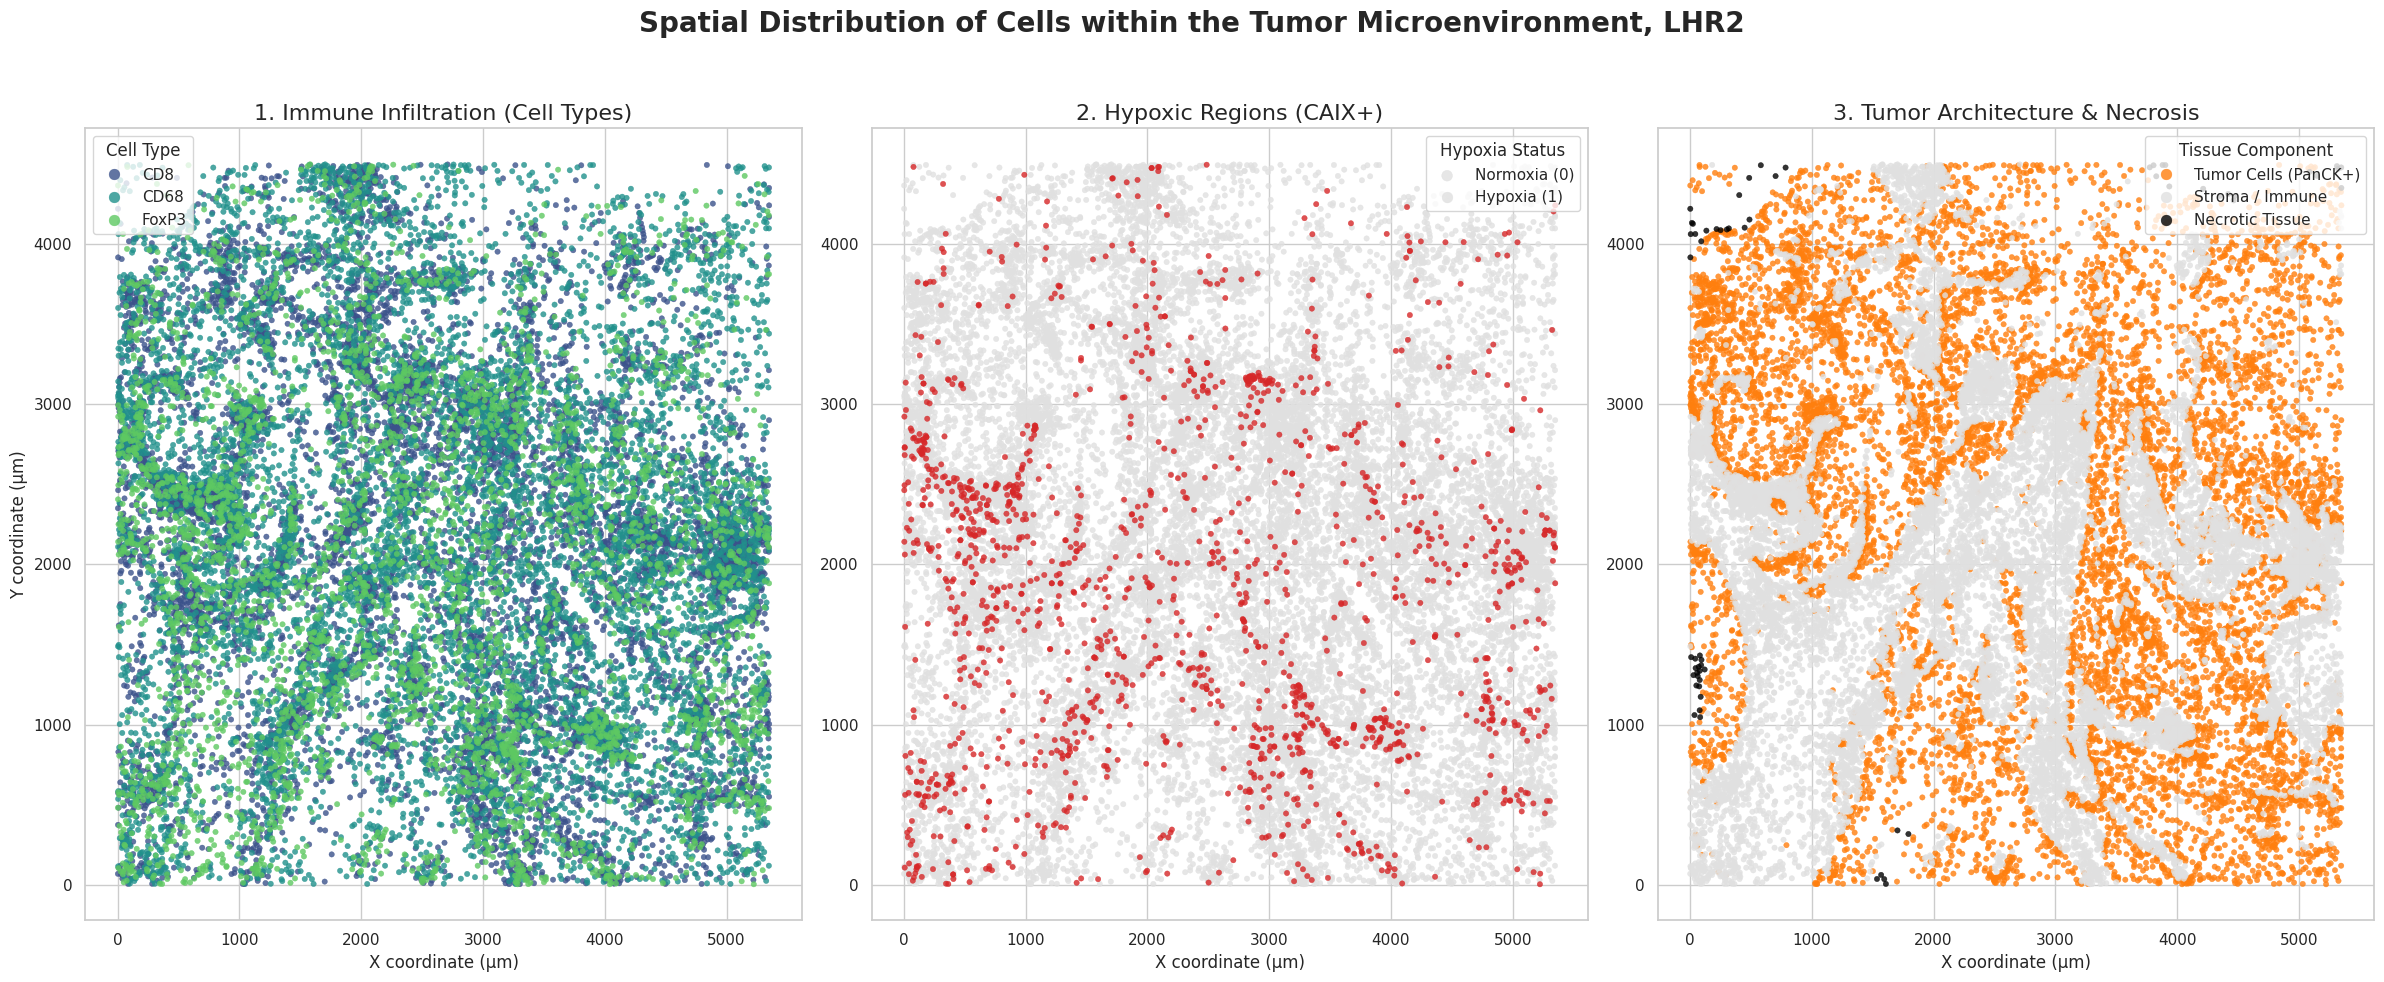

In [11]:
df2 = LHR2.copy()

conditions = [
    (df2['Necrosis'] == 1),
    (df2['PanCK+'] == 1)
]
choices = ['Necrotic Tissue', 'Tumor Cells (PanCK+)']
df2['Tissue_Structure'] = np.select(conditions, choices, default='Stroma / Immune')

fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.suptitle('Spatial Distribution of Cells within the Tumor Microenvironment, LHR2', fontsize=20, fontweight='bold')

sns.scatterplot(
    data=df2, x='x', y='y', hue='Celltype', 
    palette={'CD8': '#3b528b', 'CD68': '#21918c', 'FoxP3': '#5ec962'}, 
    s=15, alpha=0.8, edgecolor=None, ax=axes[0]
)
axes[0].set_title('1. Immune Infiltration (Cell Types)', fontsize=16)
axes[0].set_xlabel('X coordinate (µm)', fontsize=12)
axes[0].set_ylabel('Y coordinate (µm)', fontsize=12)
axes[0].legend(title='Cell Type', markerscale=2)


df2_sorted_hypoxia = df2.sort_values(by='CAIX+') 

sns.scatterplot(
    data=df2_sorted_hypoxia, x='x', y='y', hue='CAIX+', 
    palette={0: '#e0e0e0', 1: '#d62728'}, #Grey Normoxia, Red Hypoxia
    s=15, alpha=0.8, edgecolor=None, ax=axes[1]
)
axes[1].set_title('2. Hypoxic Regions (CAIX+)', fontsize=16)
axes[1].set_xlabel('X coordinate (µm)', fontsize=12)
axes[1].set_ylabel('')
axes[1].legend(title='Hypoxia Status', labels=['Normoxia (0)', 'Hypoxia (1)'], markerscale=2)

df2_sorted_structure = df2.sort_values(by='Tissue_Structure', ascending=False)

sns.scatterplot(
    data=df2_sorted_structure, x='x', y='y', hue='Tissue_Structure', 
    palette={'Stroma / Immune': '#e0e0e0', 'Tumor Cells (PanCK+)': '#ff7f0e', 'Necrotic Tissue': '#000000'}, 
    s=15, alpha=0.8, edgecolor=None, ax=axes[2]
)
axes[2].set_title('3. Tumor Architecture & Necrosis', fontsize=16)
axes[2].set_xlabel('X coordinate (µm)', fontsize=12)
axes[2].set_ylabel('')
axes[2].legend(title='Tissue Component', markerscale=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])

Calculating 1500 points...


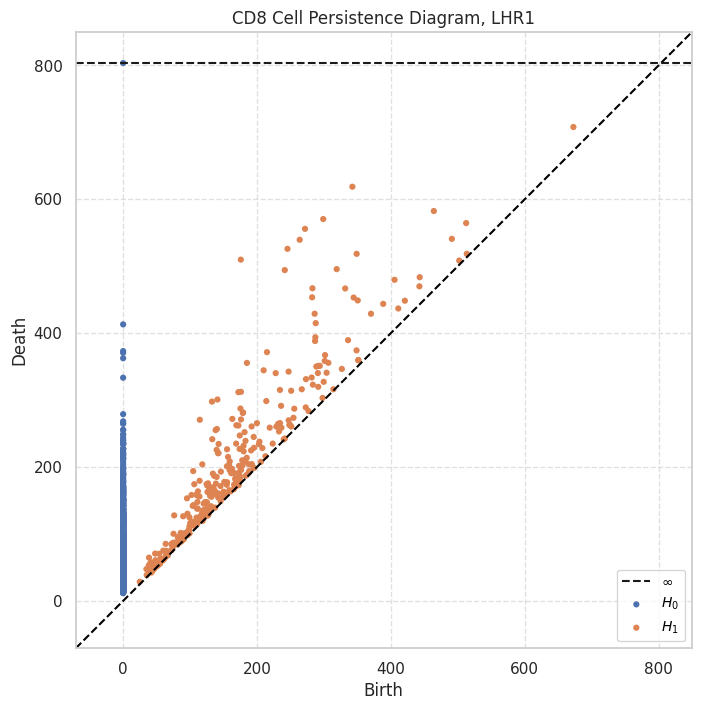

In [15]:
cd8_data1 = LHR1[LHR1['Celltype'] == 'CD8'][['x', 'y']].values

np.random.shuffle(cd8_data1)
cd8_data1 = cd8_data1[:1500]  #Subsample, calculation too long

print(f"Calculating {len(cd8_data1)} points...")
result = ripser.ripser(cd8_data1, maxdim=1)
diagrams = result['dgms']

plt.figure(figsize=(8, 8))
persim.plot_diagrams(diagrams, show=False, title="CD8 Cell Persistence Diagram, LHR1", 
              labels=['$H_0$', '$H_1$'])

plt.xlabel("Birth", fontsize=12)
plt.ylabel("Death", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)


Calculating 1500 points...


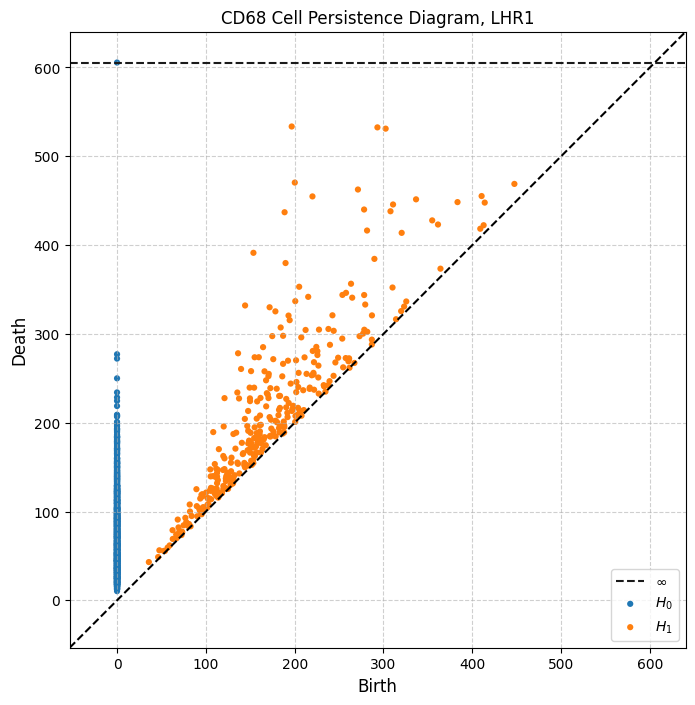

In [16]:
cd68_data1 = LHR1[LHR1['Celltype'] == 'CD68'][['x', 'y']].values

np.random.shuffle(cd68_data1)
cd68_data1 = cd68_data1[:1500]  #Subsample, calculation too long

print(f"Calculating {len(cd68_data1)} points...")
result = ripser.ripser(cd68_data1, maxdim=1)
diagrams = result['dgms']

plt.figure(figsize=(8, 8))
persim.plot_diagrams(diagrams, show=False, title="CD68 Cell Persistence Diagram, LHR1", 
              labels=['$H_0$', '$H_1$'])

plt.xlabel("Birth", fontsize=12)
plt.ylabel("Death", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

Calculating 1500 points...


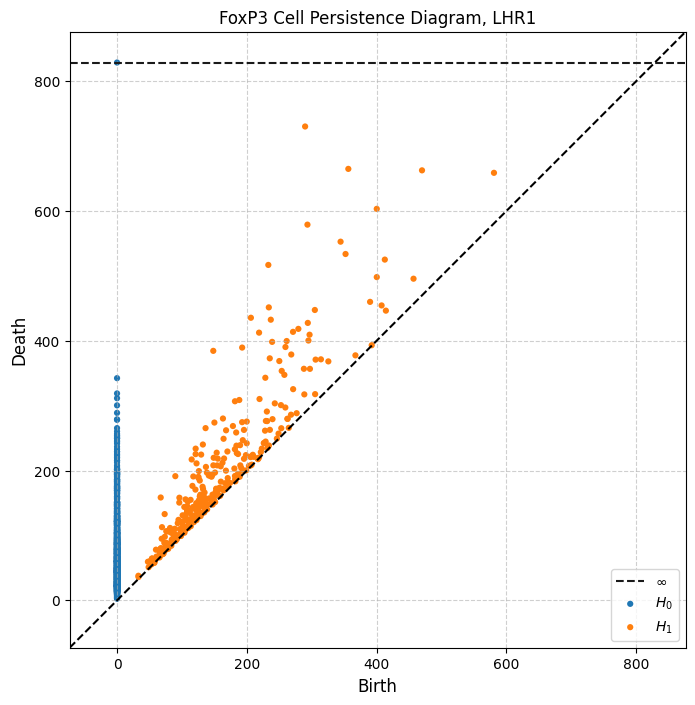

In [17]:
foxp3_data1 = LHR1[LHR1['Celltype'] == 'FoxP3'][['x', 'y']].values

np.random.shuffle(foxp3_data1)
foxp3_data1 = foxp3_data1[:1500]  #Subsample, calculation too long

print(f"Calculating {len(foxp3_data1)} points...")
result = ripser.ripser(foxp3_data1, maxdim=1)
diagrams = result['dgms']

plt.figure(figsize=(8, 8))
persim.plot_diagrams(diagrams, show=False, title="FoxP3 Cell Persistence Diagram, LHR1", 
              labels=['$H_0$', '$H_1$'])

plt.xlabel("Birth", fontsize=12)
plt.ylabel("Death", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

Calculating 1500 points...


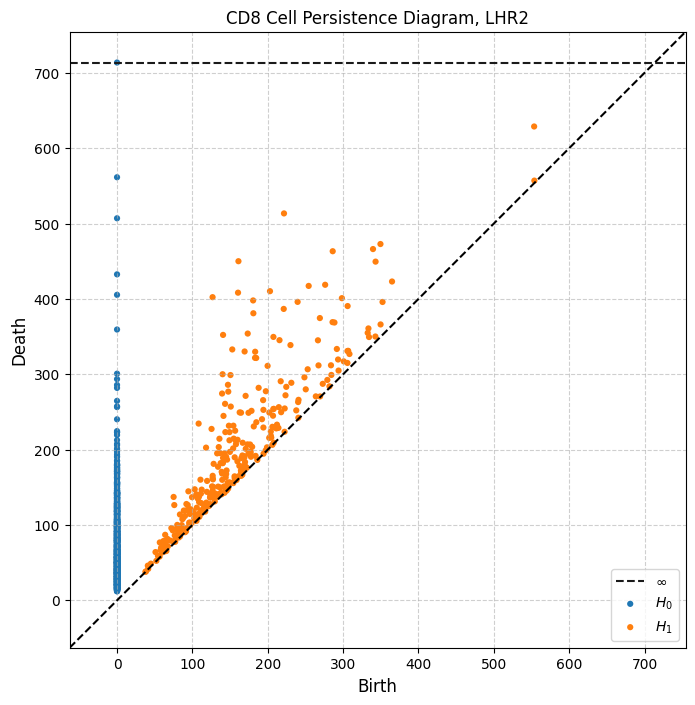

In [18]:
cd8_data2 = LHR2[LHR2['Celltype'] == 'CD8'][['x', 'y']].values

np.random.shuffle(cd8_data2)
cd8_data2 = cd8_data2[:1500]  #Subsample, calculation too long

print(f"Calculating {len(cd8_data2)} points...")
result = ripser.ripser(cd8_data2, maxdim=1)
diagrams = result['dgms']

plt.figure(figsize=(8, 8))
persim.plot_diagrams(diagrams, show=False, title="CD8 Cell Persistence Diagram, LHR2", 
              labels=['$H_0$', '$H_1$'])

plt.xlabel("Birth", fontsize=12)
plt.ylabel("Death", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)


Calculating 1500 points...


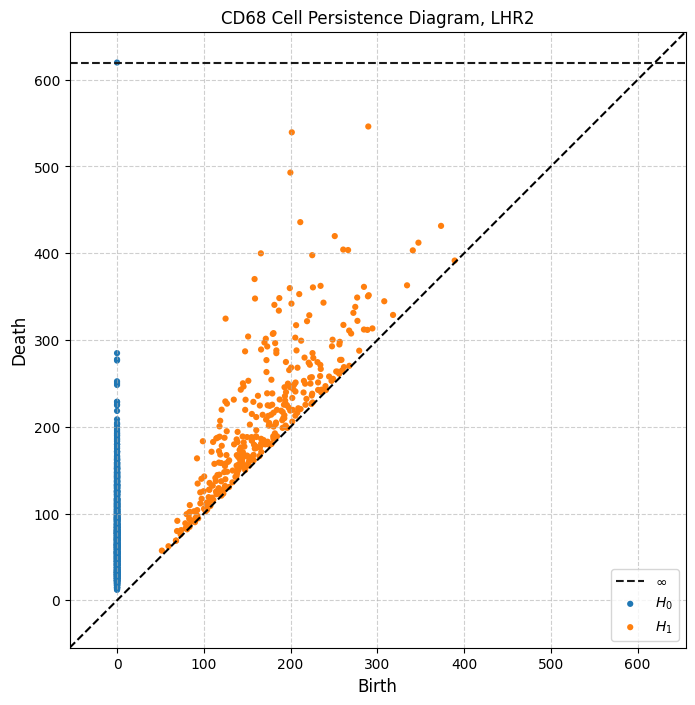

In [19]:
cd68_data2 = LHR2[LHR2['Celltype'] == 'CD68'][['x', 'y']].values

np.random.shuffle(cd68_data2)
cd68_data2 = cd68_data2[:1500]  #Subsample, calculation too long

print(f"Calculating {len(cd68_data2)} points...")
result = ripser.ripser(cd68_data2, maxdim=1)
diagrams = result['dgms']

plt.figure(figsize=(8, 8))
persim.plot_diagrams(diagrams, show=False, title="CD68 Cell Persistence Diagram, LHR2", 
              labels=['$H_0$', '$H_1$'])

plt.xlabel("Birth", fontsize=12)
plt.ylabel("Death", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

Calculating 1500 points...


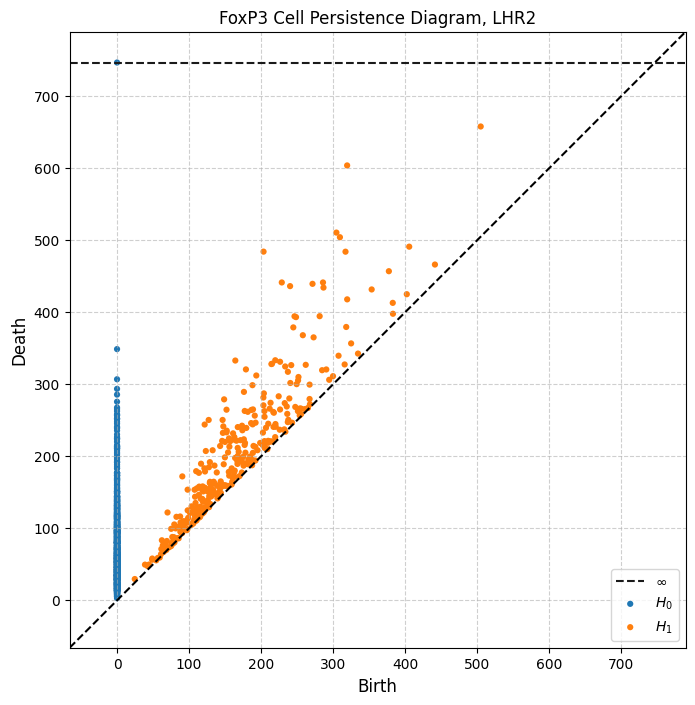

In [20]:
foxp3_data2 = LHR2[LHR2['Celltype'] == 'FoxP3'][['x', 'y']].values

np.random.shuffle(foxp3_data2)
foxp3_data2 = foxp3_data2[:1500]  #Subsample, calculation too long

print(f"Calculating {len(foxp3_data2)} points...")
result = ripser.ripser(foxp3_data2, maxdim=1)
diagrams = result['dgms']

plt.figure(figsize=(8, 8))
persim.plot_diagrams(diagrams, show=False, title="FoxP3 Cell Persistence Diagram, LHR2", 
              labels=['$H_0$', '$H_1$'])

plt.xlabel("Birth", fontsize=12)
plt.ylabel("Death", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)